# Multivariate t (Student) Distribution

`MultivariateT(mean, cov, df)` generalizes Student's t-distribution to several dimensions -- the heavy-tailed counterpart of the `MultivariateNormal`. Each draw is a vector of correlated values; `mean` is the location, `cov` is the scale (shape) matrix, and `df` sets the tail weight.

In [21]:
from symbulate import *

## Draw a value

Each draw is a vector, one entry per dimension.

In [22]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).draw()

(-1.1225103889389043, -0.597861433873005)

## Simulate

Every simulated value is a 2-dimensional vector.

In [23]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).sim(1000)

0,"(0.517062281295588, 1.2262451484525334)"
1,"(0.6543327307627136, -1.904492042426149)"
2,"(-0.44549862946534885, -1.126793972896486)"
3,"(-0.30161211096635104, 0.5993003540913389)"
4,"(1.4354873688076994, -0.8351572620606309)"
5,"(0.08067556720864945, -0.660140607581287)"
6,"(0.4362058056510173, 0.14874001114118718)"
7,"(-0.07853036234606853, 1.093806993047846)"
8,"(-2.63782870449048, -0.16677723394910182)"
...,...
999,"(-0.21881830517570056, 0.471349842805723)"


## Mean, variance, and standard deviation

For `df > 2` all the moments exist. `mean()` is the location vector; `var()` and `sd()` are the per-component variances and standard deviations, taken from the diagonal of the covariance (which is inflated relative to the scale matrix by the heavy tails).

In [24]:
X = MultivariateT(mean=[1, 2, 3], cov=[[4, 1, 0.5], [1, 2, -0.3], [0.5, -0.3, 1]], df=5)
X.mean(), X.var(), X.sd()

((1, 2, 3),
 (6.666666666666667, 3.3333333333333335, 1.6666666666666667),
 (2.581988897471611, 1.8257418583505538, 1.2909944487358056))

## Covariance matrix

The `cov` argument is the *scale* matrix, not the covariance. The actual covariance is `df / (df - 2)` times it.

In [25]:
X.cov()

array([[ 6.66666667,  1.66666667,  0.83333333],
       [ 1.66666667,  3.33333333, -0.5       ],
       [ 0.83333333, -0.5       ,  1.66666667]])

## Correlation matrix

The `df / (df - 2)` factor cancels out when the covariance is rescaled to correlations, so the correlation matrix matches that of the scale matrix. Its diagonal is 1.

In [26]:
X.corr()

array([[ 1.        ,  0.35355339,  0.25      ],
       [ 0.35355339,  1.        , -0.21213203],
       [ 0.25      , -0.21213203,  1.        ]])

## Evaluate the pdf at a point

In [27]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).pdf([0, 0])

np.float64(0.15915494309189535)

## Relationship: each marginal is a Student's t

Each component of a multivariate t is a univariate Student's t with the same `df`, centered at that component's mean and scaled by the square root of its diagonal scale entry. Here the first component of `MultivariateT([3, 7], [[4, 0], [0, 9]], df=5)` is `3 + 2 * StudentT(5)` (location 3, scale sqrt(4) = 2).

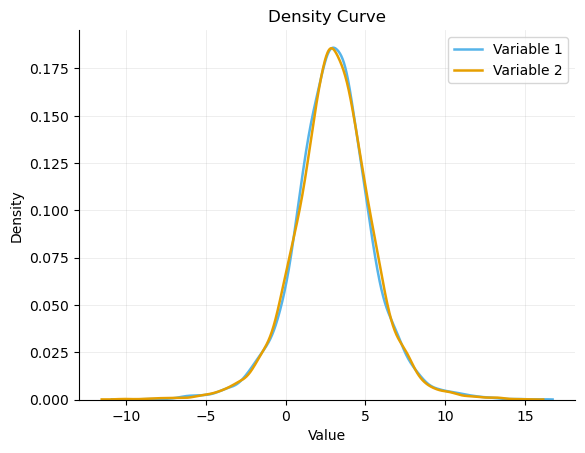

In [28]:
X, Y = RV(MultivariateT(mean=[3, 7], cov=[[4, 0], [0, 9]], df=5))
X.sim(10000).plot(type="density")
(3 + 2 * RV(StudentT(df=5))).sim(10000).plot(type="density")

## Relationship: large df approaches the multivariate normal

With `df = 1000` the marginal is very close to the corresponding normal.

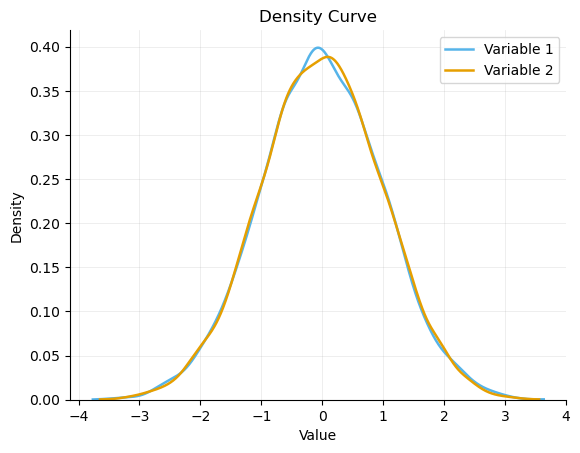

In [29]:
Xbig, _ = RV(MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=1000))
Xnorm, _ = RV(MultivariateNormal(mean=[0, 0], cov=[[1, 0], [0, 1]]))
Xbig.sim(10000).plot(type="density")
Xnorm.sim(10000).plot(type="density")